In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import astropy.units as u
import astropy.constants as const
import pandas as pd
import pickle as pkl
import seaborn as sns
import matplotlib as mpl
from astropy.io import fits
from astropy.table import Table
from lmfit import Model
from cycler import cycler
from empirical_functions import spectrum, ModelFitting, convolve_lsf

# Convenience Functions

In [2]:
def mask_contamination(labline, mask_dict):
    mask_idx = mask_dict[labline]
    if isinstance(mask_idx, list):
        mask=np.ones(300, dtype=bool)
        mask[mask_idx[0]:mask_idx[1]] = False
        return mask
    else:
        mask=np.zeros(300, dtype=bool)
        mask[mask_idx:] = True
        return mask
    
# labline: mask array
line_mask_dict = {
    1453.1:200,
    1555.89:[75,175],
    1463.83:200,
    1613.72:[75,200],
    1415.33:180,
    1407.29:200,
    1468.39:[75,299], #mask out MgII transition at 1466.55
    1407.29: [75,250],
    1435.05: [80,299], #High velocity component
    1636.34: [75,190]
}

In [10]:
disp_df = pd.read_pickle('data/BC_conf_dispdf.pkl')
lsf_df = pd.read_pickle('data/BC_conf_LSFdf.pkl')

#Models
def gaussian(x, amp, sig, cen, bgl):
    x = np.array(x)
    y = amp * np.exp(-((x - cen)**2.0)/(2.0 * (sig**2.0))) + bgl
    return y

def double_gauss(x, amp1, sig1, cen1, amp2, sig2, cen2, bgl):
    y = gaussian(x, amp1, sig1, cen1,0) + gaussian(x, amp2, sig2, cen2,0) + bgl
    return y


def gaussian_conv(x, amp, sig, cen, bgl, lsf_file, disptab, cenwave, filt, segment):
    x = np.array(x)
    y = amp * np.exp(-((x - cen)**2.0)/(2.0 * (sig**2.0))) + bgl
    
    _, y_conv = convolve_lsf(x, y, lsf_df, disp_df, lsf_file, disptab, cenwave, filt, segment)
    
    return y_conv

def double_gauss_conv(x, amp1, sig1, cen1, amp2, sig2, cen2, bgl, lsf_file, disptab, cenwave, filt, segment):
    x = np.array(x)
    y = gaussian(x, amp1, sig1, cen1, 0) + gaussian(x, amp2, sig2, cen2, 0) + bgl
    _, y_conv = convolve_lsf(x, y, lsf_df, disp_df, lsf_file, disptab, cenwave, filt, segment)
    return y_conv

In [11]:
def radial_velocity(wavelengths, labline):
    velocity = (wavelengths - labline*u.AA)/(labline*u.AA) * const.c.to(u.km/u.s)
    vsini = velocity#/np.sin(np.radians(16))
    return vsini

def radial_velocity_error(errors, labline):
    vel_error = np.abs((const.c.to(u.km/u.s))/(labline*u.AA))*errors
    vsini_err = vel_error#/np.sin(np.radians(16))
    return vsini_err

def gaussian(x, amp, sig, cen, bgl):
    x = np.array(x)
    y = amp * np.exp(-((x - cen)**2.0)/(2.0 * (sig**2.0))) + bgl
    return y

def calculate_chi2(df):
    chi2_single = []
    chi2_double = []
    red_chi2_single = []
    red_chi2_double = []

    for _, row in df.iterrows():
        f_obs = np.array(row['flux'], dtype=float)
        f_err = np.array(row['fluxerr'], dtype=float)
        f_model_single = np.array(row['gauss_flux'], dtype=float)
        f_model_double = np.array(row['double_gauss_flux'], dtype=float)

        # apply mask if labline has one
        if row['labline'] in line_mask_dict.keys():
            mask = mask_contamination(row['labline'], line_mask_dict)
            f_obs = f_obs[~mask]
            f_err = f_err[~mask]

        chi2_1 = np.sum(((f_obs - f_model_single) / f_err) ** 2)
        chi2_2 = np.sum(((f_obs - f_model_double) / f_err) ** 2)
        chi2_single.append(chi2_1)
        chi2_double.append(chi2_2)

        #calculate reeduced chi2
        red_chi2_1 = chi2_1/(len(f_obs) - len(row['params1']))
        red_chi2_2 = chi2_2/(len(f_obs) - len(row['params2']))
        red_chi2_single.append(red_chi2_1)
        red_chi2_double.append(red_chi2_2)

    return red_chi2_single, red_chi2_double

In [12]:
def make_gauss_from_params(x, params):
    if len(params) == 4:
        return gaussian(x, params['amp'][0], params['sig'][0], params['cen'][0], params['bgl'][0])
    if len(params) == 7:
        return [gaussian(x, params['amp1'][0], params['sig1'][0], params['cen1'][0], params['bgl'][0]), gaussian(x, params['amp2'][0], params['sig2'][0], params['cen2'][0], params['bgl'][0])]
def plot_fits(df, transition, plot_vel=False):
    subset = df[df['transition']==transition].reset_index(drop=True)
    #chi2 values to add to residuals plot
    chi2_1, chi2_2 = calculate_chi2(subset)
    for i, row in subset.iterrows():
        flux = row['flux'].value
        fluxerr = row['fluxerr'].value
        wave = row['wavelength']#.value
        vel_data = radial_velocity(wave, row['labline']).value
        
        ygauss = row['gauss_flux'].value
        ygausserr = row['gauss_fluxerr'].value

        y2gauss = row['double_gauss_flux'].value
        y2gausserr = row['double_gauss_fluxerr'].value
        
        waveconv = row['conv_wavelength']#.value
        vel_conv = radial_velocity(waveconv, row['labline']).value

        fig, ax = plt.subplots(2,2, figsize = (9,5), sharex=True, gridspec_kw={'height_ratios':[3,1]}, layout='constrained')
        fig.subplots_adjust(hspace=0, wspace=0)
        if plot_vel:
            #data
            ax[0,0].plot(vel_data, flux, '--', label='emission line')
            ax[0,0].fill_between(vel_data, flux-fluxerr, flux+fluxerr, color='tab:blue', alpha=0.2)
            ax[0,1].plot(vel_data, flux, '--', label='emission line')
            ax[0,1].fill_between(vel_data, flux-fluxerr, flux+fluxerr, color='tab:blue', alpha=0.2)
            
            #fits
            ygauss1, ygauss2 = make_gauss_from_params(waveconv, row['params2'])

            ax[0,0].plot(vel_conv, ygauss, label='single conv gauss')
            ax[0,0].fill_between(vel_conv, ygauss-ygausserr, ygauss+ygausserr, color='red', alpha=0.4,)

            ax[0,1].plot(vel_conv, ygauss1, label='1')
            ax[0,1].plot(vel_conv, ygauss2, label='2')

            ax[0,0].set_title(f"BIC = {row['BIC1']}")
            ax[0,1].set_title(f"BIC = {row['BIC2']}")

            ax[0,1].plot(vel_conv, y2gauss, label='double conv gauss')
            ax[0,1].fill_between(vel_conv, y2gauss-y2gausserr, y2gauss+y2gausserr, color='red', alpha=0.4,)

            #residuals
            if row['labline'] in line_mask_dict:
                mask = mask_contamination(row['labline'], line_mask_dict)
                masked_flux = flux[~mask]
                masked_fluxerr = fluxerr[~mask]
            else:
                masked_flux = flux
                masked_fluxerr = fluxerr

            ax[1,0].errorbar(vel_conv, masked_flux-ygauss, yerr=masked_fluxerr, ms=5, lw=0, marker='.', elinewidth=0.3, label=rf'$\chi^2_\nu$:{chi2_1[i]:0.2f}')
            ax[1,0].hlines(0, min(vel_conv), max(vel_conv), 'r', '--')
            ax[1,0].legend(loc=1)
            ax[1,1].errorbar(vel_conv, masked_flux-y2gauss, yerr=masked_fluxerr, ms=5, lw=0, marker='.', elinewidth=0.3, label=rf'$\chi^2_\nu$:{chi2_2[i]:0.2f}')
            ax[1,1].hlines(0, min(vel_conv), max(vel_conv), 'r', '--')
            ax[1,1].legend(loc=1)

            #parameter labels
            for i, param in enumerate(row['params2']):
                ax[0,1].text(0.05, 0.95-(i*0.05), f"{param} = {row['params2'][param][0]:.2e}",
                                transform=ax[0,1].transAxes, verticalalignment='top')
            
            for i, param in enumerate(row['params1']):
                ax[0,0].text(0.05, 0.95-(i*0.05), f"{param} = {row['params1'][param][0]:.2e}",
                                transform=ax[0,0].transAxes, verticalalignment='top')

            fig.supxlabel(r'Velocity (km s$^{-1}$)')
        else:
            #data
            ax[0,0].plot(wave.value, flux, '--', label='emission line')
            ax[0,0].fill_between(wave.value, flux-fluxerr, flux+fluxerr, color='tab:blue', alpha=0.2)
            ax[0,1].plot(wave.value, flux, '--', label='emission line')
            ax[0,1].fill_between(wave.value, flux-fluxerr, flux+fluxerr, color='tab:blue', alpha=0.2)

            #fits
            ygauss1, ygauss2 = make_gauss_from_params(wave, row['params2'])

            ax[0,0].plot(waveconv.value, ygauss, label='single conv gauss')
            ax[0,0].fill_between(waveconv.value, ygauss-ygausserr, ygauss+ygausserr, color='red', alpha=0.4,)

            ax[0,1].plot(wave, ygauss1, label='1')
            ax[0,1].plot(wave, ygauss2, label='2')

            ax[0,0].set_title(f"BIC = {row['BIC1']:.3f}")
            ax[0,1].set_title(f"BIC = {row['BIC2']:.3f}")

            ax[0,1].plot(waveconv.value, y2gauss, label='double conv gauss')
            ax[0,1].fill_between(waveconv.value, y2gauss-y2gausserr, y2gauss+y2gausserr, color='red', alpha=0.4,)

            #residuals
            if row['labline'] in line_mask_dict:
                mask = mask_contamination(row['labline'], line_mask_dict)
                masked_flux = flux[~mask]
                masked_fluxerr = fluxerr[~mask]
            else:
                masked_flux = flux
                masked_fluxerr = fluxerr

            ax[1,0].errorbar(waveconv.value, masked_flux-ygauss, yerr=masked_fluxerr, ms=5, lw=0, marker='.', elinewidth=0.3, label=rf'$\chi^2_\nu$:{chi2_1[i]:0.2f}')
            ax[1,0].hlines(0, min(waveconv.value), max(waveconv.value), 'r', '--')
            ax[1,1].errorbar(waveconv.value, masked_flux-y2gauss, yerr=masked_fluxerr, ms=5, lw=0, marker='.', elinewidth=0.3, label=rf'$\chi^2_\nu$:{chi2_2[i]:0.2f}')
            ax[1,1].hlines(0, min(waveconv.value), max(waveconv.value), 'r', '--')

            for i, param in enumerate(row['params2']):
                ax[0,1].text(0.05, 0.95-(i*0.05), f"{param} = {row['params2'][param][0]:.2e}",
                                transform=ax[0,1].transAxes, verticalalignment='top')
            
            for i, param in enumerate(row['params1']):
                ax[0,0].text(0.05, 0.95-(i*0.05), f"{param} = {row['params1'][param][0]:.2e}",
                                transform=ax[0,0].transAxes, verticalalignment='top')

            fig.supxlabel(r'Wavelength ($\AA$)')
            
        ax[0,0].legend()
        ax[0,1].legend()
        fig.supylabel(r'Flux ($erg \AA^{-1} s^{-2} cm^{-2}$)')
        fig.suptitle(f"{row['transition']} {row['labline']} {row['obsdate']}")
        ax[1,0].set_ylim(-1e-13,1e-13)
        ax[1,1].set_ylim(-1e-13,1e-13)
        
        ax[0,0].set_ylim(0,1e-12)
        ax[0,1].set_ylim(0,1e-12)
        plt.show()

# Load and Prep Data

In [5]:
line_df = pd.read_pickle(os.path.join('data', 'line_df_coadded_bootstrapped_run2.pkl'))
blue_df = pd.read_pickle(os.path.join('data', 'blue_df_coadded_bootstrapped_run2.pkl'))
red_df = pd.read_pickle(os.path.join('data', 'red_df_coadded_bootstrapped_run2.pkl'))

all_df = pd.concat([blue_df, line_df, red_df])

def SNR(signal, noise):
    return np.mean(signal/noise)

def snr_mask(df, low, high):
    ratio = df.apply(lambda r: SNR(r['gauss_flux'], r['gauss_fluxerr']) /
                               SNR(r['flux'], r['fluxerr']), axis=1)
    return df[ratio.between(low, high)]

#Drop low-SNR lines
red_df_cut  = snr_mask(red_df,  1.5, 13)
blue_df_cut = snr_mask(blue_df, 1.5, 16)
line_df_cut = snr_mask(line_df, 0.8, 100)

def peak_mask(df, thresh):
    ratio = df.apply(lambda r: max(r['gauss_flux'].value)/r['params1']['bgl'][0], axis=1)
    mask = np.array(ratio) > thresh
    return ratio, df[mask].copy()

#Drop lines with low peak-significance
red_df_ratio, red_df_peak  = peak_mask(red_df_cut,  1.5)
blue_df_ratio, blue_df_peak = peak_mask(blue_df_cut, 1.5)
line_df_ratio, line_df_peak = peak_mask(line_df_cut, 1.5)

all_df_pruned = pd.concat([blue_df_peak, line_df_peak, red_df_peak])
wanted = set(all_df_pruned['transition'])

BIC_df = all_df_pruned[all_df_pruned['transition'].isin(wanted)].copy()

#Percentile difference in BIC, current thresholding method
BIC_percentile = (BIC_df['BIC1'] - BIC_df['BIC2'])/BIC_df['BIC1']
BIC_conf = BIC_df[(BIC_percentile<=0.25) & (BIC_percentile>0)]

print('# of lines in SNR and peak significance pruned df: ', len(BIC_df))
print('# of lines after using crude BIC cut from pruned df: ', len(BIC_conf))

# of lines in SNR and peak significance pruned df:  56
# of lines after using crude BIC cut from pruned df:  23


In [6]:
def sort_BC(df):
    double_gauss_params = df['params2']

    both_BC1 = []
    both_BC2 = []

    for param_dict in double_gauss_params:
        wider = param_dict['sig1'] > param_dict['sig2'] # if gauss1 is broader it will be true
        dimmer = param_dict['amp1'] < param_dict['amp2'] # if gauss1 is dimmer it will be true
        both_BC1.append(wider == True and dimmer == True) # Usually true, frequently not
        both_BC2.append(wider == False and dimmer == False)
        
    both_BC1 = np.array(both_BC1)
    both_BC2 = np.array(both_BC2)

    BC_1_definitely = df[both_BC1]
    BC_2_definitely = df[both_BC2]

    #now only consider unsure lines
    #lines where both is false is unsure
    unsure = df.iloc[np.argwhere((both_BC1 == False) & (both_BC2 == False)).ravel()]
    if len(unsure)>0:
        wider_1 = []
        for param_dict in unsure['params2']:
            wider = param_dict['sig1'] > param_dict['sig2'] # if gauss1 is broader it will be true
            wider_1.append(wider)
        wider_1 = np.array(wider_1)

        BC_1_maybe = unsure[wider_1]
        BC_2_maybe = unsure[~wider_1]
    else:
        BC_1_maybe = None
        BC_2_maybe = None

    return BC_1_definitely, BC_2_definitely, BC_1_maybe, BC_2_maybe

BC_1_conf, BC_2_conf, conf_maybe1, conf_maybe2 = sort_BC(BIC_df.copy())

#collate all broad component params and NC params separately, do manually for maybes

BC_1_conf['BC_params'] = BC_1_conf['params2'].apply(
                                                    lambda p: {
                                                        'ampBC': p['amp1'],
                                                        'sigBC': p['sig1'],
                                                        'cenBC': p['cen1'],
                                                        'bgl': p['bgl']
                                                    }
                                                )
BC_1_conf['NC_params'] = BC_1_conf['params2'].apply(
                                                    lambda p: {
                                                        'ampNC': p['amp2'],
                                                        'sigNC': p['sig2'],
                                                        'cenNC': p['cen2'],
                                                        'bgl': p['bgl']
                                                    }
                                                )

BC_2_conf['BC_params'] = BC_2_conf['params2'].apply(
                                                    lambda p: {
                                                        'ampBC': p['amp2'],
                                                        'sigBC': p['sig2'],
                                                        'cenBC': p['cen2'],
                                                        'bgl': p['bgl']
                                                    }
                                                )
BC_2_conf['NC_params'] = BC_2_conf['params2'].apply(
                                                    lambda p: {
                                                        'ampNC': p['amp1'],
                                                        'sigNC': p['sig1'],
                                                        'cenNC': p['cen1'],
                                                        'bgl': p['bgl']
                                                    }
                                                )
BC_conf = pd.concat([BC_1_conf, BC_2_conf])

# Simulate Data

In [7]:
print(np.unique(BC_conf['labline'], return_counts=True))
print(np.unique(BC_conf['transition'], return_counts=True))
print(len(BC_conf))

(array([1398.95, 1407.29, 1415.33, 1431.01, 1446.12, 1460.17, 1463.83,
       1467.08, 1468.39, 1489.57, 1500.45, 1504.76, 1521.59, 1555.89,
       1588.8 , 1591.32, 1613.72, 1636.34]), array([1, 1, 1, 4, 4, 4, 4, 2, 1, 4, 4, 4, 2, 2, 2, 1, 3, 3]))
(array(['[0,1]', '[0,2]', '[0,3]', '[1,4]', '[1,7]', '[2,12]', '[3,0]',
       '[4,13]', '[4,4]'], dtype=object), array([ 7,  4,  2, 16,  6,  4,  4,  1,  3]))
47


## Sample data
Since the parameters are correlated, to sample from the *set* of parameters for one line. This means for each unique labline, we will end up with:
1. One single and one double gaussian *original set of model parameters* (with errors). If there are multiple examples of the emission lines, samples will be taken from each individual model.
2. Construct an N-dimensional gaussian distribution with the parameters' 1-$\sigma$ gaussian errors. N=4 for the single gauss model, and N=6 for the double gauss case
3. Draw 100 samples from the N-dimensional gaussian, and construct a noiseless simulated emission line.
4. Convolve the gaussian with the COS LSF
5. Randomly draw from this set of residuals to add realistic noise to the simulated emission lines. If the model is masked, the simulated line will also be cut to the mask since we know which emission line this simulated line corresponds to.
6. Calculate the SNR in 5 bins: two wings and one center bin
7. Fit both the gaussian and double gauss models to the simulated data and get the model parameters and BIC values for each.

Then we move on to the ML

The limitation of this is that the classification will be specialized to this data. Any new data will need new data to be simulated and the models and ML classification to be run again.

## Noise
HST COS data noise sources:
<ul>
    <li>Poisson noise: Detector counting statistical noise</li> 
    <li>Dark noise: Varies with the solar cycle</li>
    <li>Gain sag: Detector wears down and the amount of electrons per photon begins to vary over the detector. Detectors also miscalculate the location of the photon incident event.</li>
    <li>Fixed pattern noise: usually removed by flat-fielding but there's wires, weirdly shaped pixels, and it's dependent on lifetime position</li>
</ul>
All of this noise is grating, detector location, and time dependent. <br>
Since simulating all of this is complicated and a lot of work, I will be using noise directly seen in the continuum of the spectrum. The limitation this poses is that results might be biased towards performance in the wings and the behaviour of noise in the signal part of the line is not accurately represented.<br><br>

The errors are sampled from HASP calculated, co-added by labline flux-errors. This is the pixel-to-pixel error in the flux estimate, which includes the Poisson counting noise, where systematic sources of error like fixed-pattern noise, gain sag, and dark noise are all removed. 

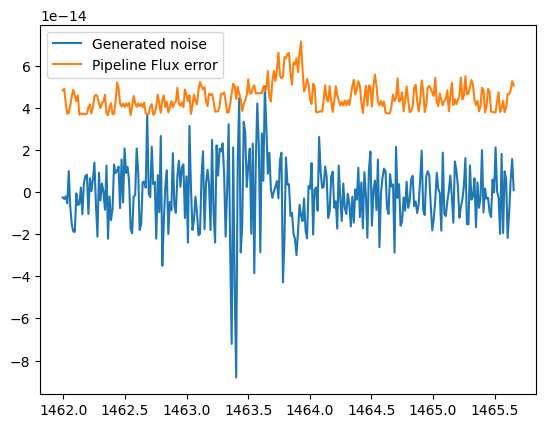

In [8]:
# Generate noise
rng = np.random.default_rng()

def make_some_noise(df):
    # fluxerr is the pixel-by-pixel error in the HST flux calculation
    # This accounts for all types of noise including Poisson    
    idx = rng.integers(low=0, high=len(df))
    fluxerr = df.iloc[idx]['fluxerr'].value

    # HASP accounts for and has methods of removing autocorrelation
    # so sampling from a normal scaled by fluxerr gives realistic noise
    noise = rng.normal(loc=0, scale=np.abs(fluxerr))
    #reassign outliers to 4-sigma
    noise = rng.normal(loc=0, scale=np.abs(fluxerr))
    noise = np.clip(noise, -3*fluxerr, 3*fluxerr)
    return noise, fluxerr  # return both
    
plt.plot(BC_conf.iloc[0]['wavelength'].value, make_some_noise(BC_conf)[0], label='Generated noise')
plt.plot(BC_conf.iloc[0]['wavelength'].value, make_some_noise(BC_conf)[1], label='Pipeline Flux error')
plt.legend()
plt.show()

## Testing and Diagnostics

In [13]:
row = BC_conf.iloc[0]
# Read in original data and model estimates, get the range of fit parameters for NC, BC and single
# Create 1 and 2 gauss models from parameters

single_params = row['params1'].values()
BC_params = row['BC_params']
NC_params = row['NC_params']
bgl = row['params2']['bgl']

# Single model means and covariance
single_means = [param[0] for param in single_params]
cov_single = np.diag(np.array([param[1] for param in single_params])**2)

# BC is always 1 and NC is always 2 now
double_errs = (
    [BC_params[k][1] for k in ['ampBC', 'sigBC', 'cenBC']] +
    [NC_params[k][1] for k in ['ampNC', 'sigNC', 'cenNC']] +
    [bgl[1]]
)

double_means = (
    [BC_params[k][0] for k in ['ampBC', 'sigBC', 'cenBC']] +
    [NC_params[k][0] for k in ['ampNC', 'sigNC', 'cenNC']] +
    [bgl[0]]
)
cov_double = np.diag(np.array(double_errs)**2)

single_param_samples = np.random.multivariate_normal(single_means, cov_single, size = 100)
double_param_samples = np.random.multivariate_normal(double_means, cov_double, size = 100)

lsf_file=row['LSFfile']
disptab=row['dispfile']
cenwave=row['cenwave']
filt=row['filter']
segment=row['segment']

#Now build simulated gaussian
sim_single = []
sim_double = []
sim_wavelength = []
sim_noise = []
for i in range(100):
    single_sample = single_param_samples[i]
    double_sample = double_param_samples[i]
    amp1, sig1, cen1, amp2, sig2, cen2, bgl_val = double_sample
    #convolve the gaussian
    single_model = gaussian_conv(
                                row['wavelength'], 
                                single_sample[0], 
                                single_sample[1], 
                                single_sample[2], 
                                single_sample[3], 
                                lsf_file, disptab, cenwave, filt, segment)

    # 1st gauss is always broad and second gauss is always narrow
    double_model = double_gauss_conv(row['wavelength'], amp1, sig1, cen1, amp2, sig2, cen2, bgl_val, lsf_file, disptab, cenwave, filt, segment)
    
    #add noise
    noise = make_some_noise(BC_conf)[0]
    
    single_simulated = noise+single_model
    double_simulated = noise+double_model
    sim_single.append(single_simulated)
    sim_double.append(double_simulated)
    sim_wavelength.append(row['wavelength'])
    sim_noise.append(noise)

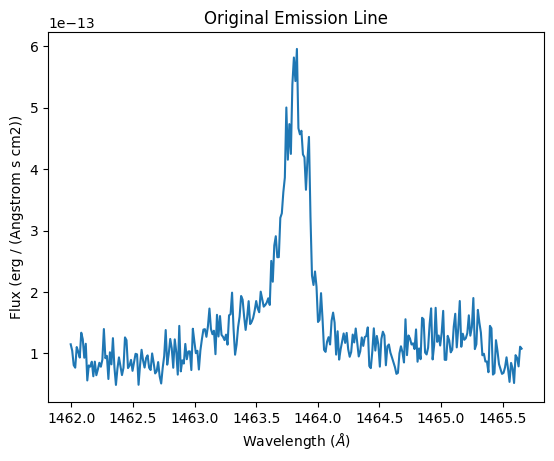

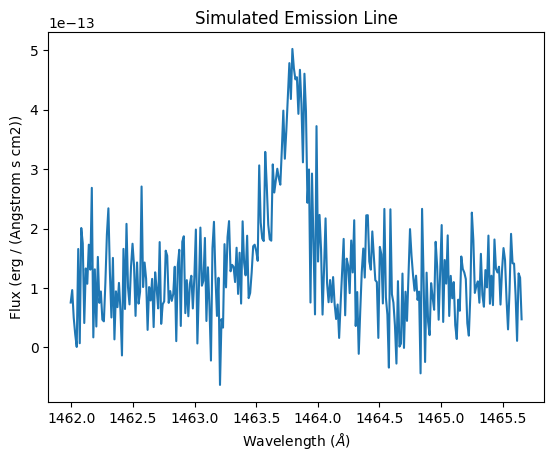

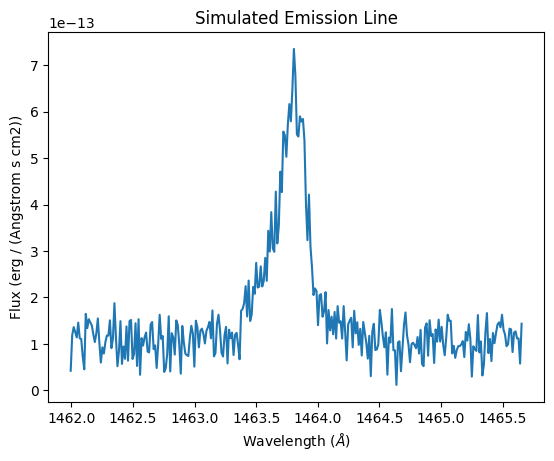

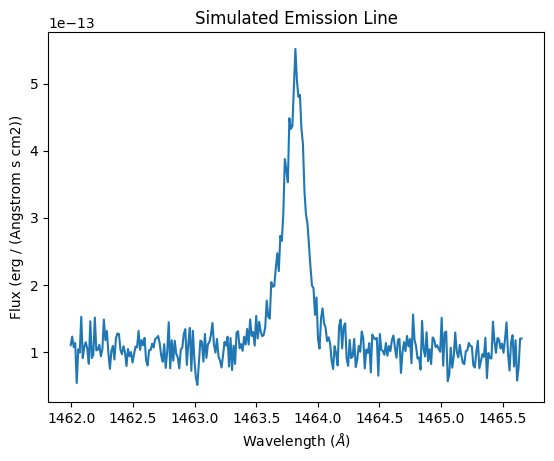

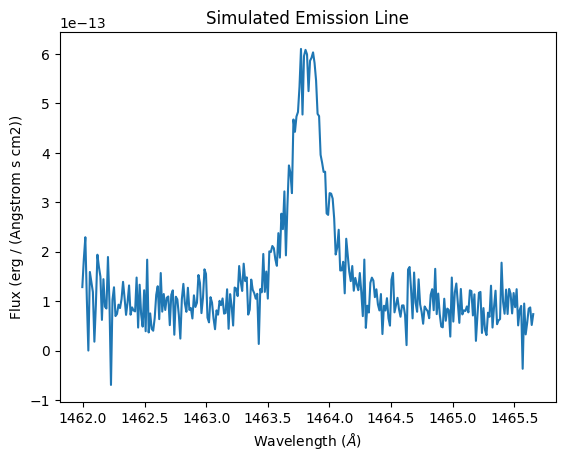

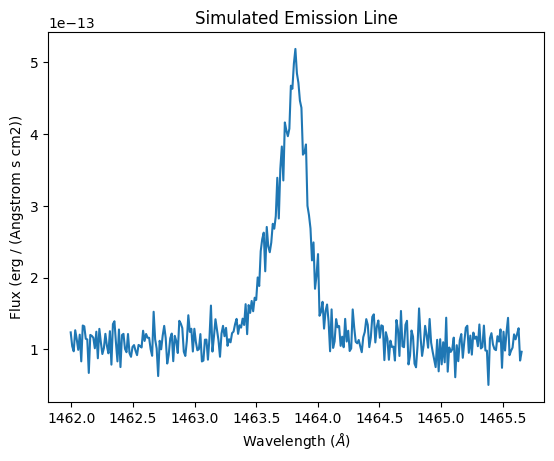

In [15]:
flux_units = row['flux'].unit
plt.plot(row['wavelength'], row['flux'])
plt.title('Original Emission Line')
plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel(fr'Flux ({flux_units})')
plt.show()
for i in rng.integers(low=0, high=len(sim_single), size=5):
    plt.plot(sim_wavelength[i], sim_double[i])
    plt.title('Simulated Emission Line')
    plt.xlabel(r'Wavelength ($\AA$)')
    plt.ylabel(fr'Flux ({flux_units})')
    plt.show()

## Simulate realistic emission lines

In [16]:
# Read in original data and model estimates, get the range of fit parameters for NC, BC and single
# Create 1 and 2 gauss models from parameters
flux_units = BC_conf.iloc[0]['flux'].unit
sim_rows = []
for i, row in BC_conf.iterrows():
    single_params = row['params1'].values()
    BC_params = row['BC_params']
    NC_params = row['NC_params']
    bgl = row['params2']['bgl']

    # Single model means and covariance
    single_means = [param[0] for param in single_params]
    single_errs = [param[1] for param in single_params]
    cov_single = np.diag(np.array(single_errs)**2)

    # BC is always 1 and NC is always 2 now
    double_errs = (
        [BC_params[k][1] for k in ['ampBC', 'sigBC', 'cenBC']] +
        [NC_params[k][1] for k in ['ampNC', 'sigNC', 'cenNC']] +
        [bgl[1]]
    )

    double_means = (
        [BC_params[k][0] for k in ['ampBC', 'sigBC', 'cenBC']] +
        [NC_params[k][0] for k in ['ampNC', 'sigNC', 'cenNC']] +
        [bgl[0]]
    )
    cov_double = np.diag(np.array(double_errs)**2)

    single_param_samples = np.random.multivariate_normal(single_means, cov_single, size = 100)
    double_param_samples = np.random.multivariate_normal(double_means, cov_double, size = 100)

    lsf_file=row['LSFfile']
    disptab=row['dispfile']
    cenwave=row['cenwave']
    filt=row['filter']
    segment=row['segment']

    #Now build simulated gaussian
    for i in range(100):
        single_sample = single_param_samples[i]
        double_sample = double_param_samples[i]
        amp1, sig1, cen1, amp2, sig2, cen2, bgl_val = double_sample
        #convolve the gaussian
        single_model = gaussian_conv(
                                    row['wavelength'], 
                                    single_sample[0], 
                                    single_sample[1], 
                                    single_sample[2], 
                                    single_sample[3], 
                                    lsf_file, disptab, cenwave, filt, segment)

        # 1st gauss is always broad and second gauss is always narrow
        double_model = double_gauss_conv(row['wavelength'], amp1, sig1, cen1, amp2, sig2, cen2, bgl_val, lsf_file, disptab, cenwave, filt, segment)
        
        #add noise
        noise, orig_err = make_some_noise(BC_conf)
        
        single_simulated = noise+single_model
        double_simulated = noise+double_model
        
        new_row1 = row.copy(deep=True)
        new_row2 = row.copy(deep=True)
        new_row1['flux'] = single_simulated*flux_units
        new_row1['fluxerr'] = orig_err*flux_units
        new_row2['flux'] = double_simulated*flux_units
        new_row2['fluxerr'] = orig_err*flux_units
        new_row1['params1_sim'] = {'amp': [single_sample[0], single_errs[0]], 'sig': [single_sample[1], single_errs[1]], 'cen': [single_sample[2], single_errs[2]], 'bgl': [single_sample[3], single_errs[3]]}
        new_row1['paramsBC_sim'] = None
        new_row1['paramsNC_sim'] = None

        new_row2['params1_sim'] = None
        new_row2['paramsBC_sim'] = {'ampBC': [amp1, BC_params['ampBC'][1]], 'sigBC': [sig1, BC_params['sigBC'][1]], 'cenBC': [cen1, BC_params['cenBC'][1]], 'bgl': [bgl_val, BC_params['bgl'][1]]}
        new_row2['paramsNC_sim'] = {'ampNC': [amp2, NC_params['ampNC'][1]], 'sigNC': [sig2, NC_params['sigNC'][1]], 'cenNC': [cen2, NC_params['cenNC'][1]], 'bgl': [bgl_val, NC_params['bgl'][1]]}
        #everything else about the row stays the same: wavelength, file information, etc. for modelling code to run

        #save the right answer
        new_row1['model_true'] = 1
        new_row2['model_true'] = 2
        
        sim_rows.append(new_row1)
        sim_rows.append(new_row2)
sims_df = pd.DataFrame(sim_rows)
sims_df = sims_df.reset_index(drop=True)

In [21]:
#sims_df.to_pickle('data/sims_df.pkl')

## Parameter distributions

In [22]:
#Claude coded

#Plot parameter distribution for original and simulated lablines
#two subplots, single and double, violin plots

def param_distribution(df, params):
    "A function to pull out all parameters and errors"
    keys = df[params].iloc[0].keys()
    keys_dict = {key: [] for key in keys}
    keys_dict_err = {key: [] for key in keys}
    for _, row  in df.iterrows():
        for key in keys:
            keys_dict[key].append(row[params][key][0])
            keys_dict_err[key].append(row[params][key][1])
    return keys_dict, keys_dict_err

def safe_param_distribution(df, param_key):
    """Like param_distribution but filters out rows where param_key is missing/None."""
    valid_df = df[df[param_key].apply(lambda x: x is not None and isinstance(x, dict))]
    if len(valid_df) == 0:
        return None, None
    return param_distribution(valid_df, param_key)

def clean_vals(vals):
    """Remove NaN, inf, and constant arrays that break violinplot KDE."""
    arr = np.array(vals, dtype=float)
    arr = arr[np.isfinite(arr)]
    return arr if (len(arr) > 1 and np.std(arr) > 0) else None

#original is BC_conf, simulated is sims_df
#plot parameter violin plots
#Each parameter will have a different subplot, each violin will be a labline
#both the original and simulated will be overplotted, 
#each labline will be colored the same but the original labline will have a lower alpha
trans_list_dict = {}

for transition in BC_conf['transition'].unique():
    lablines = BC_conf.loc[
        BC_conf['transition'] == transition, 'labline'
    ].unique()
    
    trans_list_dict[transition] = [str(line) for line in lablines]

trans_list = "\n".join(
    f"{transition}: {', '.join(lines)}"
    for transition, lines in trans_list_dict.items()
)

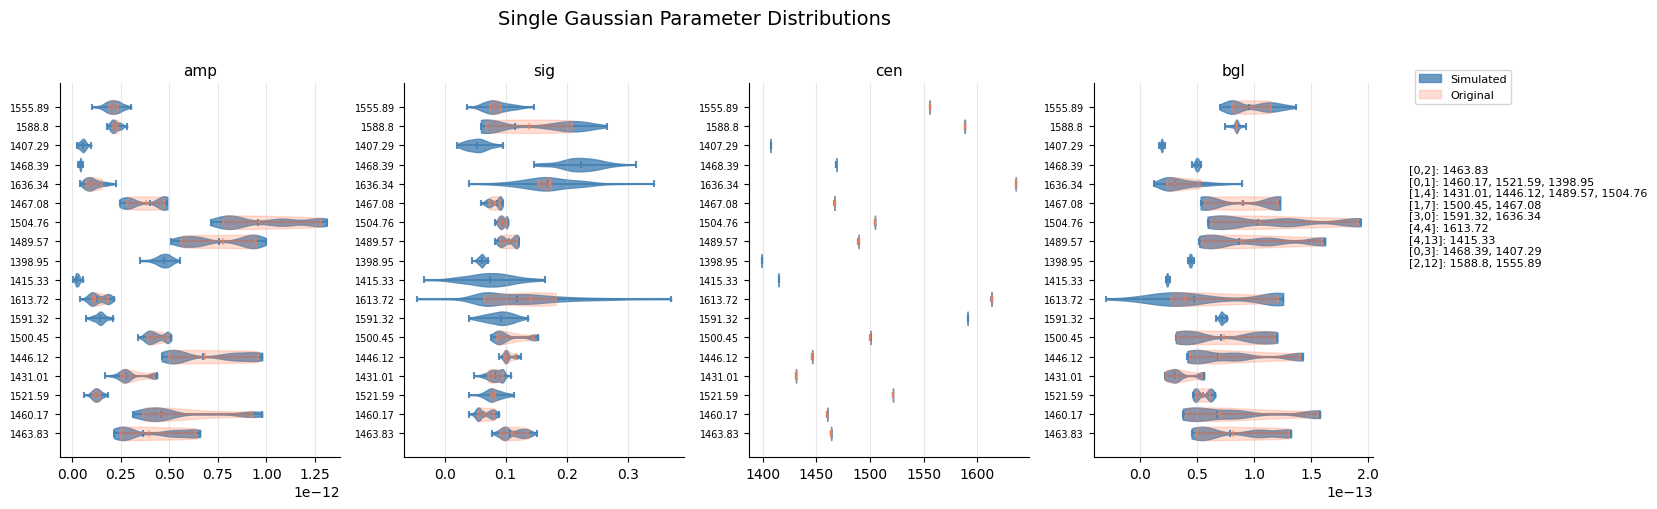

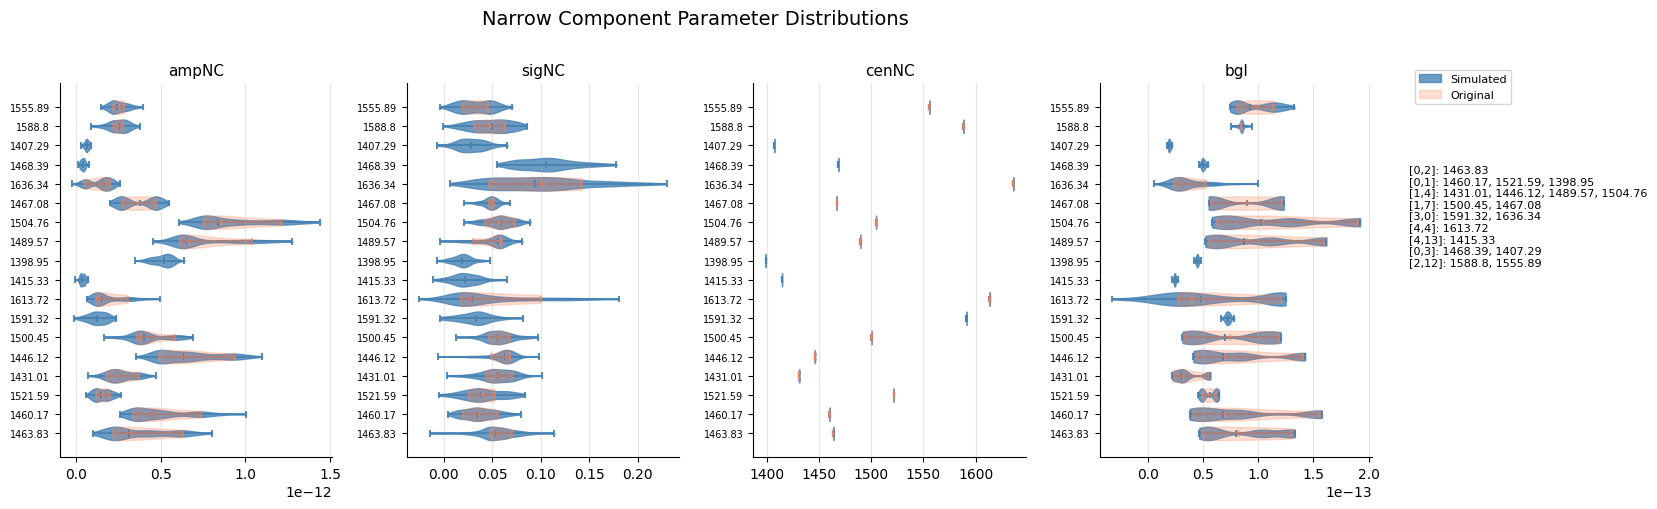

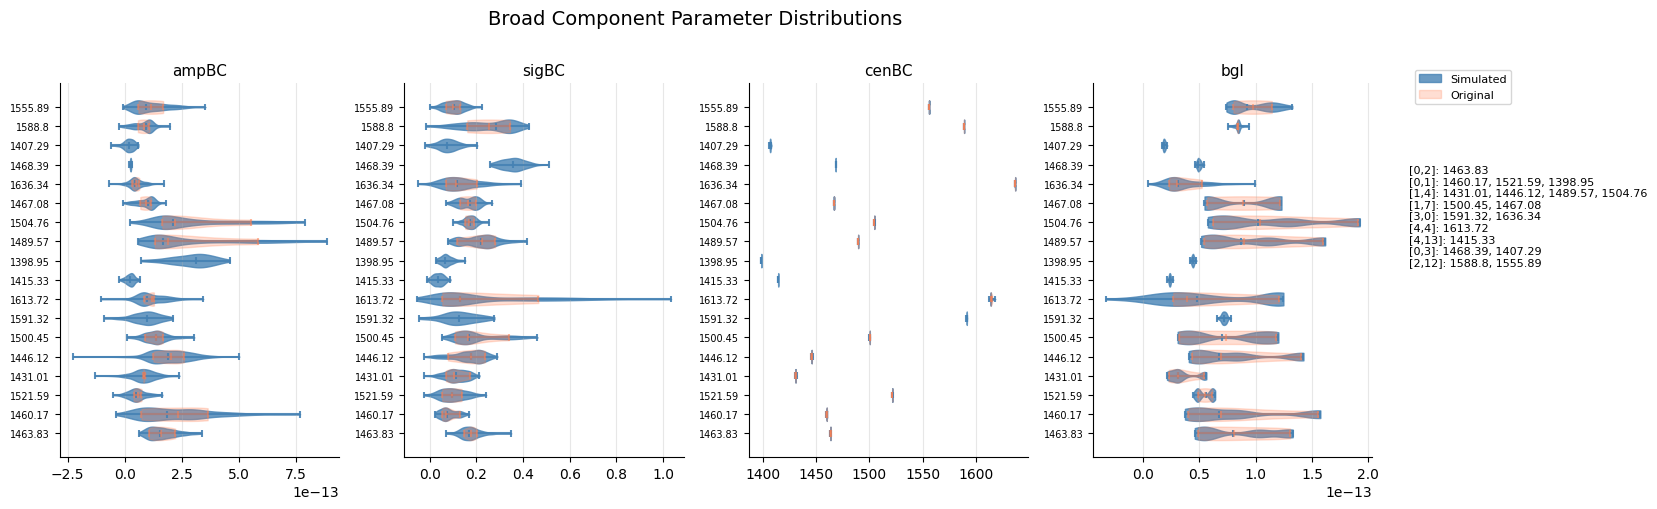

In [23]:
cmap = mpl.colormaps['gist_earth']
unique_lablines = BC_conf['labline'].unique()
labline_colors = dict(zip(unique_lablines, cmap(np.linspace(0.1, 0.9, len(unique_lablines)))))

def style_violin(vp, color, alpha_body, alpha_lines):
    for pc in vp['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(alpha_body)
    for part in ['cmedians', 'cbars', 'cmins', 'cmaxes']:
        vp[part].set_color(color)
        vp[part].set_alpha(alpha_lines)
        vp[part].set_linewidth(1.5)

param_dict = {'orig': ['params1', 'NC_params', 'BC_params'], 'sim': ['params1_sim', 'paramsNC_sim', 'paramsBC_sim']}

for idx, title in enumerate([
    'Single Gaussian Parameter Distributions',
    'Narrow Component Parameter Distributions',
    'Broad Component Parameter Distributions',
]):
    orig_param_key = param_dict['orig'][idx]
    sim_param_key  = param_dict['sim'][idx]

    fig, axs = plt.subplots(1, 4, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, y=1.01)

    for j, labline in enumerate(unique_lablines):
        orig_df = BC_conf[BC_conf['labline'] == labline]
        new_df  = sims_df[sims_df['labline'] == labline]

        orig, _ = safe_param_distribution(orig_df, orig_param_key)
        sims, _ = safe_param_distribution(new_df,  sim_param_key)

        if orig is None or sims is None:
            continue

        color = labline_colors[labline]

        for i, key in enumerate(sims.keys()):
            sims_vals = clean_vals(sims[key])
            orig_vals = clean_vals(orig[key])
            #if key != 'bgl':
            if sims_vals is not None:
                vp_sim = axs[i].violinplot(sims[key], positions=[j], showmedians=True,
                                            orientation='horizontal', widths=0.7)
                style_violin(vp_sim, 'steelblue', alpha_body=0.8, alpha_lines=0.9)

            if orig_vals is not None:
                vp_orig = axs[i].violinplot(orig[key], positions=[j], showmedians=True,
                                            orientation='horizontal', widths=0.7)
                style_violin(vp_orig, 'coral', alpha_body=0.25, alpha_lines=0.5)

                axs[i].set_title(key, fontsize=11)
                axs[i].set_yticks(range(len(unique_lablines)))
                axs[i].set_yticklabels([str(l) for l in unique_lablines], fontsize=7)
                axs[i].spines[['top', 'right']].set_visible(False)
                axs[i].grid(axis='x', alpha=0.3, linestyle='-')

    sim_patch  = mpatches.Patch(color='steelblue', alpha=0.8,  label='Simulated')
    orig_patch = mpatches.Patch(color='coral', alpha=0.25, label='Original')
    fig.legend(handles=[sim_patch, orig_patch],
               bbox_to_anchor=(1.01, 0.9), loc='upper left', fontsize=8)
    fig.text(1.01, 0.7, trans_list,
         transform=fig.transFigure, fontsize=8, verticalalignment='top')
    plt.tight_layout()
    plt.show()

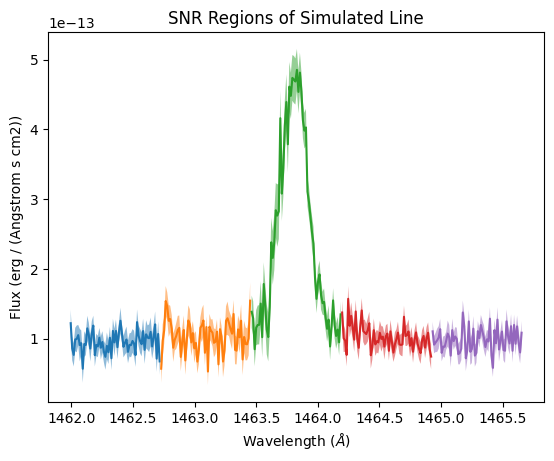

In [24]:
row_test = sims_df.iloc[0]
#high_SNR = sims_df[[np.mean(sims['flux']/sims['fluxerr'])>25000 for _,sims in sims_df.iterrows()]]
#row_test = high_SNR.iloc[0]
flux = row_test['flux'].value
wave = row_test['wavelength'].value
fluxerr = row_test['fluxerr'].value
split_idx = np.arange(len(flux))
split_idx = np.split(split_idx, 5)
split_flux = flux[split_idx]
split_fluxerr = fluxerr[split_idx]
split_wave = wave[split_idx]

for split in split_idx:
    f1 = flux[split]
    fe1 = fluxerr[split]
    w1 = wave[split]
    plt.plot(w1, f1)
    plt.fill_between(w1, f1+fe1, f1-fe1, alpha=0.5)
plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel(fr'Flux ({flux_units})')
plt.title('SNR Regions of Simulated Line')
plt.show()


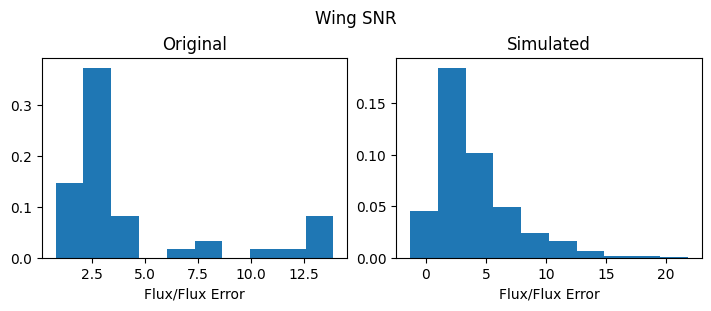

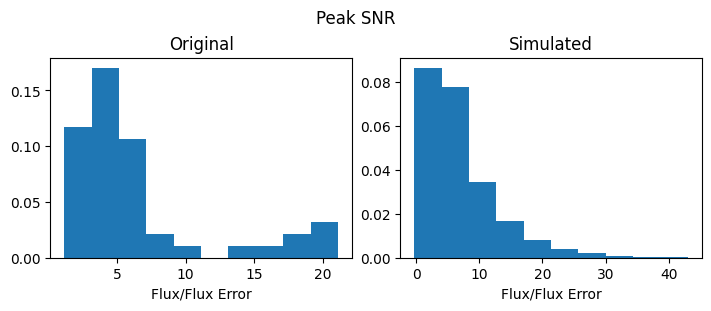

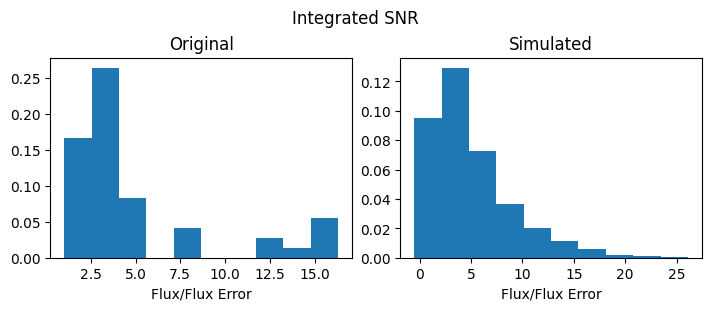

In [25]:
def compute_snr_regions(flux, fluxerr):
    
    #compute 5 regions
    split_idx = np.arange(len(flux))
    split_idx = np.split(split_idx, 3)
    split_flux = flux[split_idx]
    split_fluxerr = fluxerr[split_idx]
    
    wing_snr = np.mean(np.concatenate([split_flux[0], split_flux[-1]])/np.concatenate([split_fluxerr[0], split_fluxerr[-1]]))
    peak_snr = np.mean(split_flux[1]/split_fluxerr[1])
    integrated_snr = np.mean(flux/fluxerr)
    return wing_snr, peak_snr, integrated_snr

# Original SNR
orig_wing, orig_peak, orig_integrated = [], [], []
for idx, row in BC_conf.iterrows():
    wing_snr, peak_snr, int_snr = compute_snr_regions(
        row['flux'].value, row['fluxerr'].value
    )
    orig_wing.append(wing_snr)
    orig_peak.append(peak_snr)
    orig_integrated.append(int_snr)

# Simulated SNR
sim_wing, sim_peak, sim_integrated = [], [], []
for idx, row in sims_df.iterrows():
    wing_snr, peak_snr, int_snr = compute_snr_regions(
        row['flux'], row['fluxerr']
    )
    sim_wing.append(wing_snr)
    sim_peak.append(peak_snr)
    sim_integrated.append(int_snr)

for region in ['wing', 'peak', 'all']:
    fig, ax = plt.subplots(1,2, figsize=(7,3), layout='constrained')
    if region=='wing':
        a1, a2 = orig_wing, sim_wing
        title = 'Wing SNR'
    elif region=='peak':
        a1, a2 = orig_peak, sim_peak
        title = 'Peak SNR'
    elif region=='all':
        a1, a2 = orig_integrated, sim_integrated
        title = 'Integrated SNR'
    
    ax[0].hist(a1, density=True)
    ax[0].set_title('Original')
    ax[0].set_xlabel('Flux/Flux Error')
    ax[1].hist(a2, density=True)
    ax[1].set_xlabel('Flux/Flux Error')
    ax[1].set_title('Simulated')
    fig.suptitle(title)
    plt.show()

In [26]:
sims_df.to_pickle('data/sims_df.pkl')

# Run models on simulated lines

running in sim_fitting.py and sbatch. Fingers crossed that it works

## Plot modelling results

/tmp/ipykernel_990286/1035172393.py:26: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0, wspace=0)


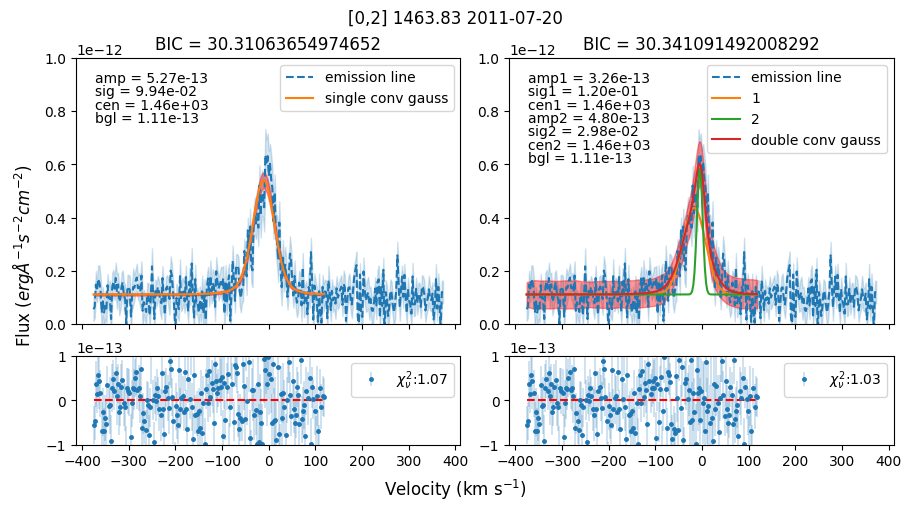

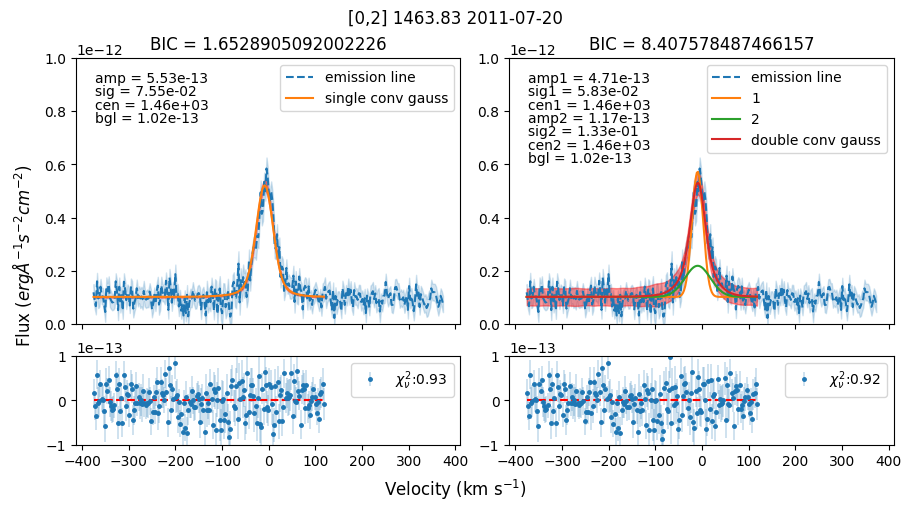

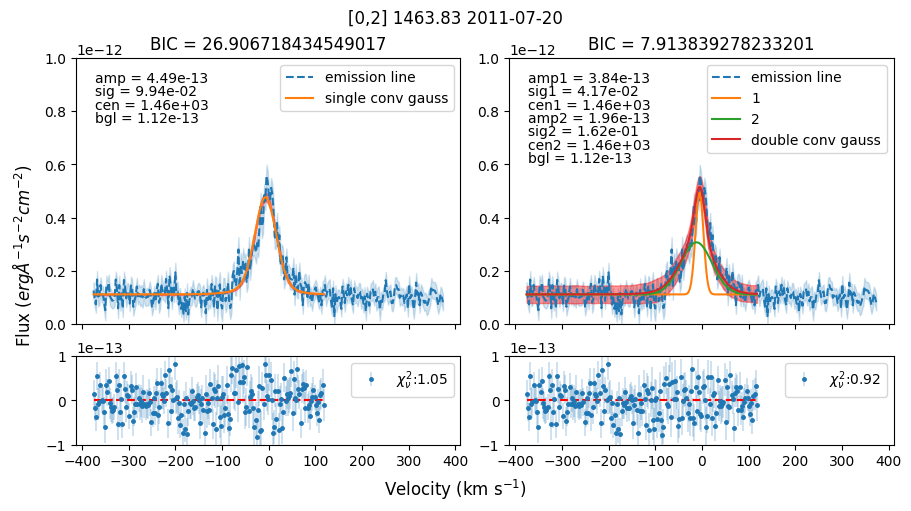

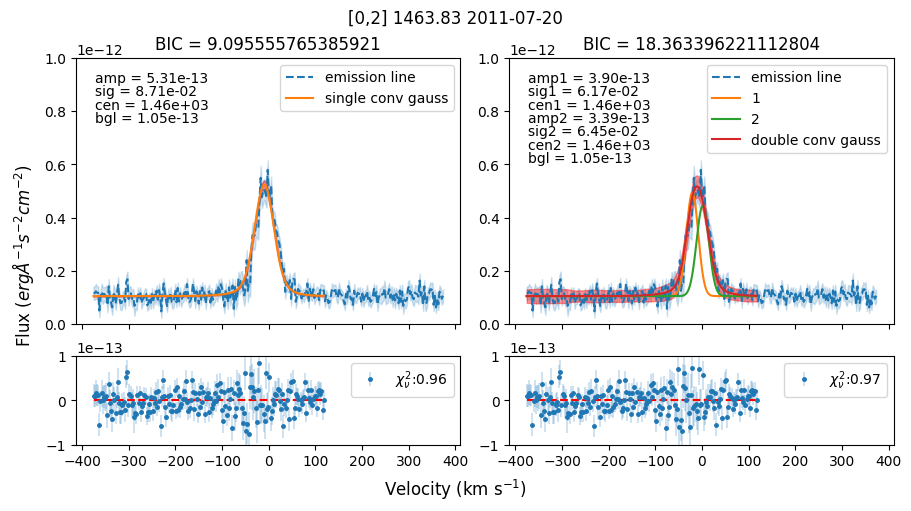

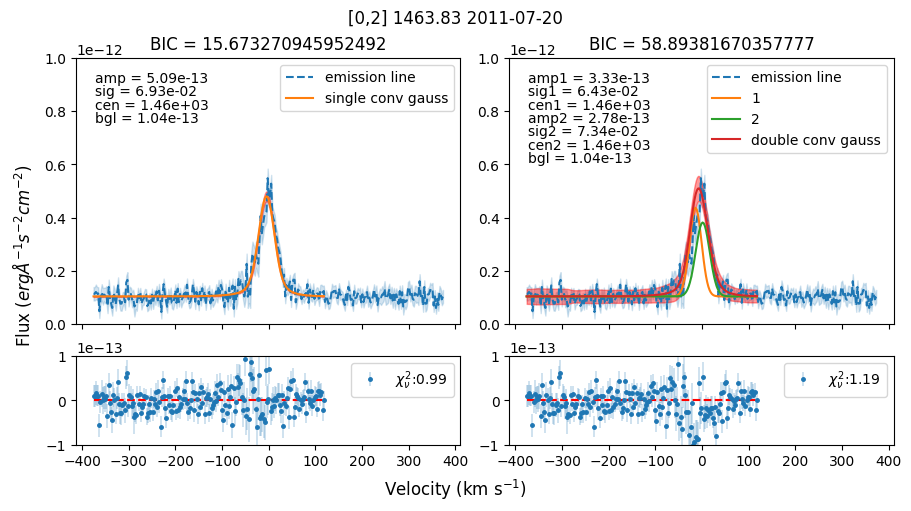

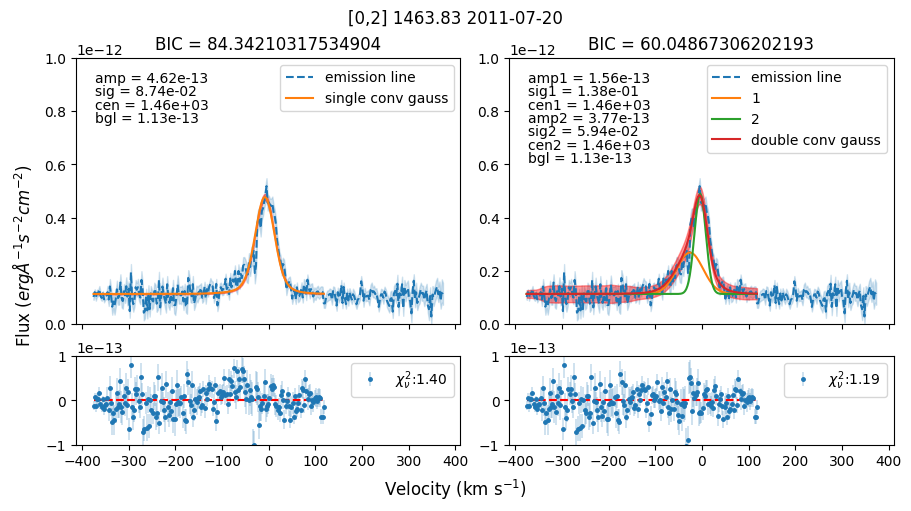

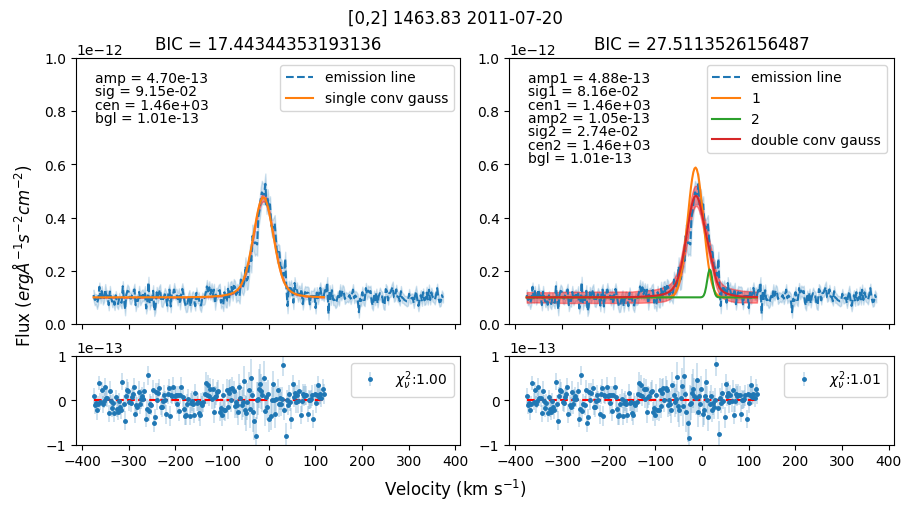

KeyboardInterrupt: 

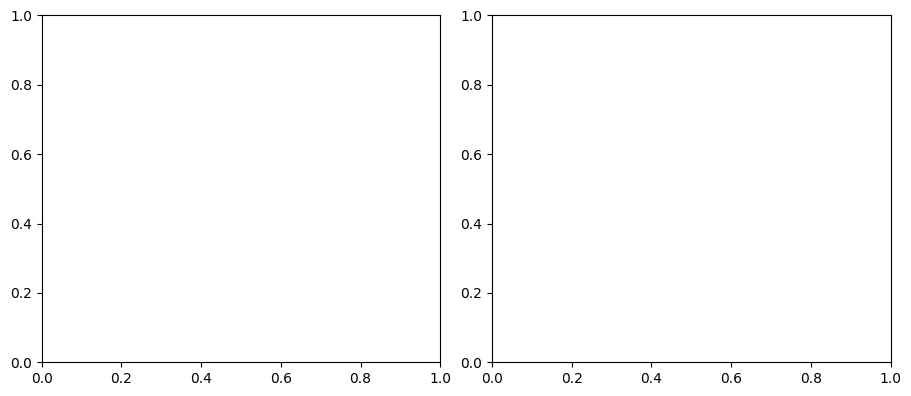

In [28]:
fitted_df = pd.read_pickle('data/sims_fitted.pkl')
for transi in fitted_df['transition'].unique():
    plot_fits(fitted_df, transition=transi, plot_vel=True)

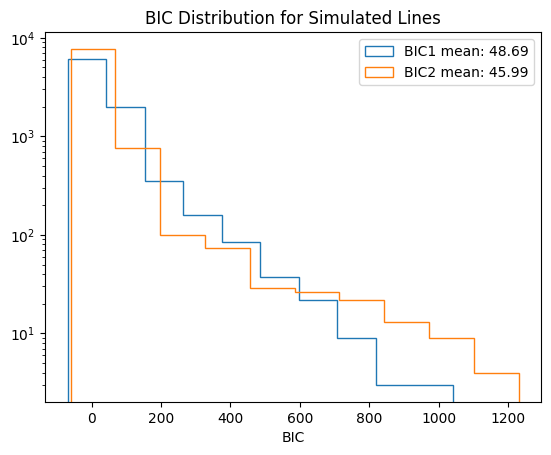

In [29]:
# BIC distribution for sims
plt.hist(fitted_df['BIC1'], label='BIC1 mean: {:.2f}'.format(fitted_df['BIC1'].mean()), histtype='step')
plt.hist(fitted_df['BIC2'], label='BIC2 mean: {:.2f}'.format(fitted_df['BIC2'].mean()), histtype='step')
plt.gca().set_yscale('log')
plt.xlabel('BIC')
plt.title('BIC Distribution for Simulated Lines')
plt.legend()
plt.show()  

# Construct a Random Forest Model with Gradient Boosting

First, get the SNR values for 5 regions along the emission line <br>
Then, construct X as: [SNR bins, BIC1, BIC2, delta_BIC, transition, labline, filter, year]
y = df['model_true']

In [31]:
print(fitted_df.keys())
print(fitted_df['model_true'].value_counts())

Index(['filename', 'obsdate', 'instrument', 'filter', 'dispfile', 'LSFfile',
       'cenwave', 'wavelength', 'flux', 'fluxerr', 'velocity', 'segment',
       'H2line_idx', 'labline', 'transition_prob', 'transition', 'year',
       'coadded_flux', 'coadded_fluxerr', 'coadded_wavelength', 'BIC1',
       'params1', 'BIC2', 'params2', 'conv_wavelength', 'gauss_flux',
       'gauss_fluxerr', 'double_gauss_flux', 'double_gauss_fluxerr',
       'BC_params', 'NC_params', 'model_true'],
      dtype='object')
model_true
2    4366
1    4364
Name: count, dtype: int64


In [32]:
def compute_5_snr_regions(flux, fluxerr):
    #compute 5 regions
    split_idx = np.arange(len(flux))
    split_idx = np.split(split_idx, 5)
    split_flux = flux[split_idx]
    split_fluxerr = fluxerr[split_idx]
    
    snr_regions = {'snr1':[], 'snr2':[], 'snr3':[], 'snr4':[], 'snr5':[]}
    for i, split in enumerate(split_idx):
        f = flux[split]
        fe = fluxerr[split]
        snr = f/fe
        snr_regions[f'snr{i+1}'].append(snr)
    
    integrated_snr = np.mean(flux/fluxerr)
    return snr_regions, integrated_snr

#Apply this to the simulated data
sim_snr_regions = []
for idx, row in fitted_df.iterrows():
    snr_regions, int_snr = compute_5_snr_regions(
        row['flux'].value, row['fluxerr'].value
    )
    sim_snr_regions.append(snr_regions)

fitted_df['snr1'] = [np.mean(snr_regions['snr1'][0]) for snr_regions in sim_snr_regions]
fitted_df['snr2'] = [np.mean(snr_regions['snr2'][0]) for snr_regions in sim_snr_regions]
fitted_df['snr3'] = [np.mean(snr_regions['snr3'][0]) for snr_regions in sim_snr_regions]
fitted_df['snr4'] = [np.mean(snr_regions['snr4'][0]) for snr_regions in sim_snr_regions]
fitted_df['snr5'] = [np.mean(snr_regions['snr5'][0]) for snr_regions in sim_snr_regions]
fitted_df['delta_BIC'] = fitted_df['BIC1'] - fitted_df['BIC2'] # positive means 2-gauss is better, negative means 1-gauss is better

In [33]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, classification_report, log_loss, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
import pickle

In [34]:
#construct training and testing X, y
training_cols = ['snr1', 'snr2', 'snr3', 'snr4', 'snr5', 'BIC1', 'BIC2', 'delta_BIC', 'transition', 'labline', 'filter', 'year']
X = fitted_df[training_cols]
y = fitted_df['model_true']  # 1 for single Gaussian, 2 for double Gaussian

# Encode categorical variables transition, labline, filter
categorical_features = ['transition', 'labline', 'filter', 'year']
encoder = OneHotEncoder(sparse_output=False)
encoder.fit(X[categorical_features])
encoded_cats = encoder.transform(X[categorical_features])
encoded_cat_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(categorical_features))
X_encoded = pd.concat([X.drop(columns=categorical_features).reset_index(drop=True), encoded_cat_df], axis=1)#.to_numpy()

#split into train and test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

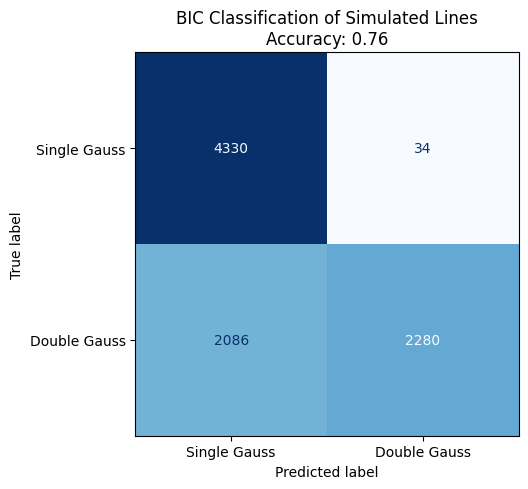

In [35]:
# preds = []
# for delta_bic  in X['delta_BIC'].values:
#     if delta_bic>0:
#         preds.append(2)
#     else:
#         preds.append(1)

# bic_classification = []
# for diff in preds-y.values:
#     if diff == 0:
#         bic_classification.append('correct')
#     else:
#         bic_classification.append('incorrect')

# plt.hist(bic_classification, label = f"Accuracy: {bic_classification.count('correct')/len(bic_classification):.2f}")
# plt.title('Classification of Simulated Lines by BIC Difference')
# plt.legend()
# plt.show()

preds = (X['delta_BIC'].values > 0).astype(int) + 1  # 1 or 2

cm = confusion_matrix(y.values, preds, labels=[1, 2])
accuracy = np.sum(np.diag(cm)) / np.sum(cm)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Single Gauss', 'Double Gauss']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'BIC Classification of Simulated Lines\nAccuracy: {accuracy:.2f}')
plt.tight_layout()
plt.show()

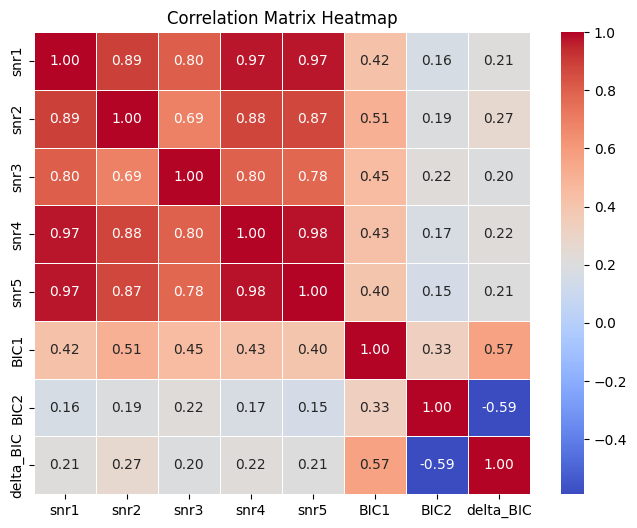

In [36]:
import seaborn as sns
correlation_matrix = X[['snr1', 'snr2', 'snr3', 'snr4', 'snr5', 'BIC1', 'BIC2', 'delta_BIC']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix Heatmap')
plt.show()

I am trying to have as few false positives (falsely classified as a double gaussian). This is due to occam's razor's principle, favoring the simpler model.

## Explore Data Properties

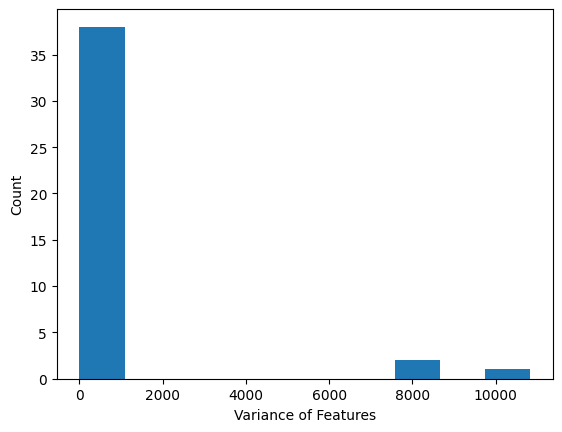

In [38]:
variances = np.var(X_encoded, axis=0)
plt.hist(variances)
plt.xlabel('Variance of Features')
plt.ylabel('Count')
plt.show()

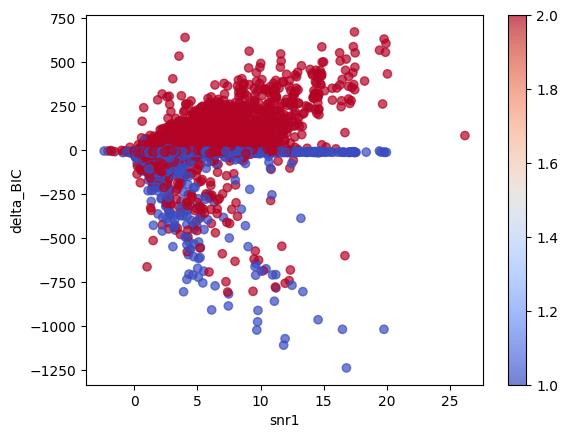

In [39]:
plt.scatter(X_encoded['snr1'], X_encoded['delta_BIC'], c=y, cmap='coolwarm', alpha=0.7)
plt.colorbar()
plt.xlabel('snr1')
plt.ylabel('delta_BIC')
plt.show()

## Construct Model

In [40]:
#Grid search for best hyperparameters
param_grid = {
    'max_depth': np.arange(2,11),
    'n_estimators': [100, 200, 500],
    'min_samples_leaf': [10, 20],
    'learning_rate': [0.05, 0.01],
    'loss': ['log_loss']
}
rf_gridsearch = GridSearchCV(GradientBoostingClassifier(random_state=0), param_grid, verbose=3, cv=5, return_train_score=True)
# rf_gridsearch.fit(X_train, y_train)

# clf = rf_gridsearch.best_estimator_
# clf.score(X_test, y_test)

In [41]:
filename = 'GB_sims.sav'
#pickle.dump(gb_model, open(filename, 'wb'))

In [42]:
gb_model = pickle.load(open(filename, 'rb'))

In [43]:
#best_params = rf_gridsearch.best_params_
best_params = gb_model.get_params()
best_params['n_estimators'] = 1000
best_params['min_samples_leaf'] = 30
print(best_params)
gb_model = GradientBoostingClassifier(**best_params)
gb_model.fit(X_train, y_train)
gb_model.score(X_test, y_test)

{'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.01, 'loss': 'log_loss', 'max_depth': np.int64(8), 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 30, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 1000, 'n_iter_no_change': None, 'random_state': None, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


0.7731958762886598

## Evaluate Model Performance
ROC curve, Precision, compare confidence score with BIC prediction, decision surface, feature importances, loss curves for training and testing

Predictions for real data, how that expands on previously determined results. Do we get more transitions?

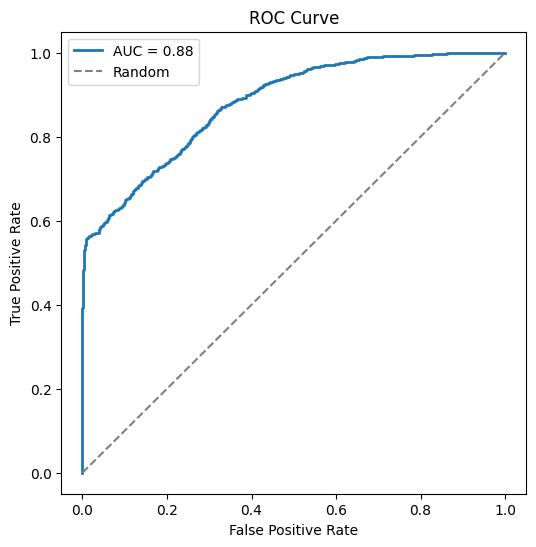

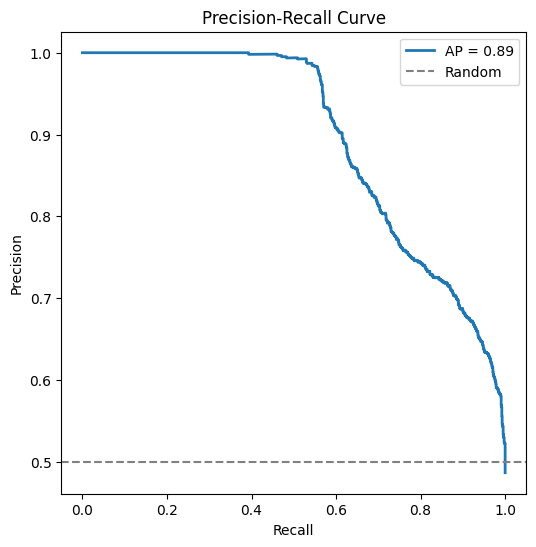

In [44]:
fig, ax = plt.subplots(figsize=(6,6))
y_test_plot = y_test.values - 1  # {1,2} → {0,1}
y_train_plot = y_train.values - 1
probs = gb_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test_plot, probs)
roc_auc = auc(fpr, tpr)

ax.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.2f}')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
fig.show()

fig, ax = plt.subplots(figsize=(6,6))
precision, recall, _ = precision_recall_curve(y_test_plot, probs)
ap = average_precision_score(y_test_plot, probs)

ax.plot(recall, precision, lw=2, label=f'AP = {ap:.2f}')
ax.axhline(y=0.5, color='gray', linestyle='--', label='Random')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
fig.show()

              precision    recall  f1-score   support

           1       0.76      0.82      0.79      1345
           2       0.79      0.73      0.76      1274

    accuracy                           0.77      2619
   macro avg       0.77      0.77      0.77      2619
weighted avg       0.77      0.77      0.77      2619



Text(0.5, 1.0, 'Model Precision 0.76')

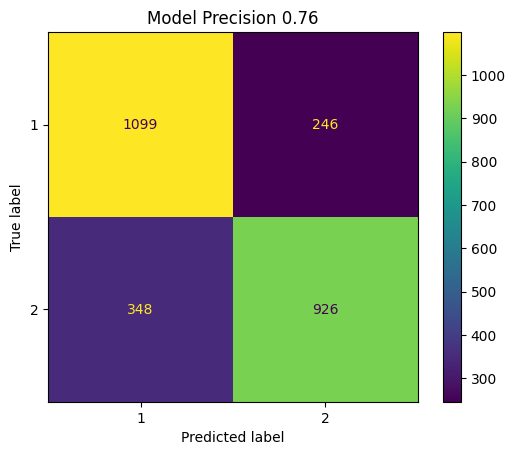

In [49]:
cm = classification_report(y_test, gb_model.predict(X_test))
print(cm)
ConfusionMatrixDisplay.from_predictions(y_test, gb_model.predict(X_test))
plt.title('Model Precision 0.76')

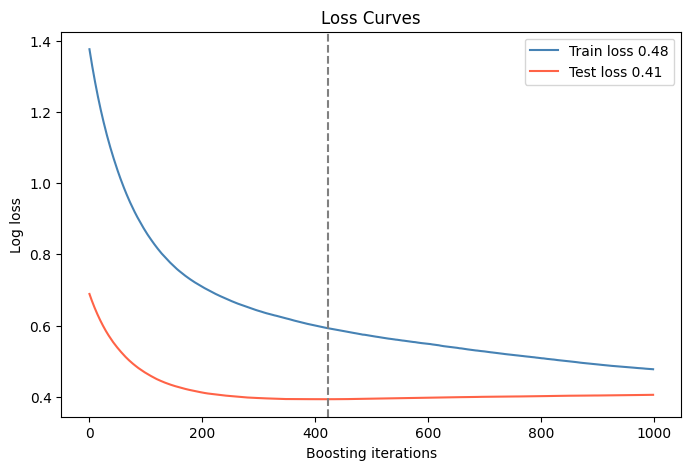

In [46]:
train_loss = gb_model.train_score_

test_loss = [log_loss(y_test, stage_probs[:, 1])
             for stage_probs in gb_model.staged_predict_proba(X_test)]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_loss, label=f'Train loss {train_loss[-1]:.2f}', color='steelblue')
ax.plot(test_loss,  label=f'Test loss {test_loss[-1]:.2f}',  color='tomato')

# Mark best iteration
best_iter = np.argmin(test_loss)
ax.axvline(best_iter, color='gray', linestyle='--')

ax.set_xlabel('Boosting iterations')
ax.set_ylabel('Log loss')
ax.set_title('Loss Curves')
ax.legend()
plt.show()

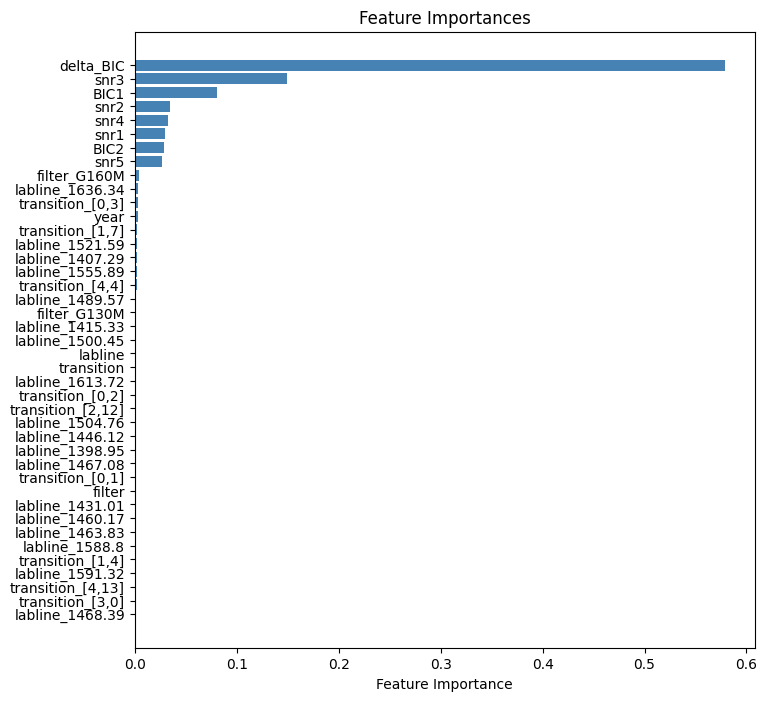

In [47]:
fig, ax = plt.subplots(figsize=(8, 8))

# Get feature importances from the base estimator
base_clf = gb_model
importances = base_clf.feature_importances_
feature_names = np.array(training_cols + list(encoder.get_feature_names_out(categorical_features)))
sorted_idx = np.argsort(importances)

ax.barh(feature_names[sorted_idx], importances[sorted_idx], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importances')
fig.show()

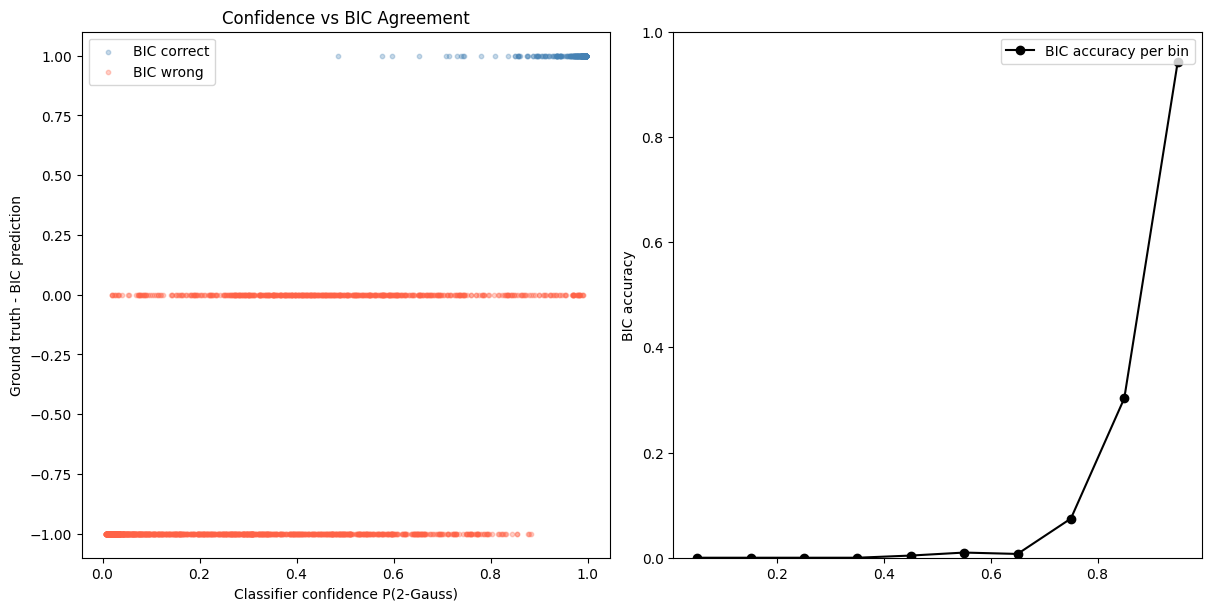

In [54]:
fig, [ax, ax2] = plt.subplots(1,2, layout='constrained', figsize=(12,6))
# BIC prediction: 1 if BIC favors double gauss (BIC2 < BIC1), else 0
bic_prediction = (X_test['delta_BIC'].values < 0).astype(int)  # adjust column name as needed
confidence = gb_model.predict_proba(X_test)[:, 1]
y_test_plot = y_test.values-1
# Split confidence by whether BIC agrees with ground truth
bic_correct = (bic_prediction == y_test_plot - 1)
bic_wrong   = ~bic_correct

ax.scatter(confidence[bic_correct], y_test_plot[bic_correct] - bic_prediction[bic_correct],
           alpha=0.3, label='BIC correct', color='steelblue', s=10)
ax.scatter(confidence[bic_wrong], y_test_plot[bic_wrong] - bic_prediction[bic_wrong],
           alpha=0.3, label='BIC wrong', color='tomato', s=10)

# Bin confidence and show BIC accuracy per bin
bins = np.linspace(0, 1, 11)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bic_acc_per_bin = [bic_correct[(confidence >= bins[i]) & (confidence < bins[i+1])].mean()
                   for i in range(len(bins)-1)]

ax2.plot(bin_centers, bic_acc_per_bin, 'ko-', label='BIC accuracy per bin')
ax2.set_ylabel('BIC accuracy')
ax2.set_ylim(0, 1)

ax.set_xlabel('Classifier confidence P(2-Gauss)')
ax.set_ylabel('Ground truth - BIC prediction')
ax.set_title('Confidence vs BIC Agreement')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
fig.show()

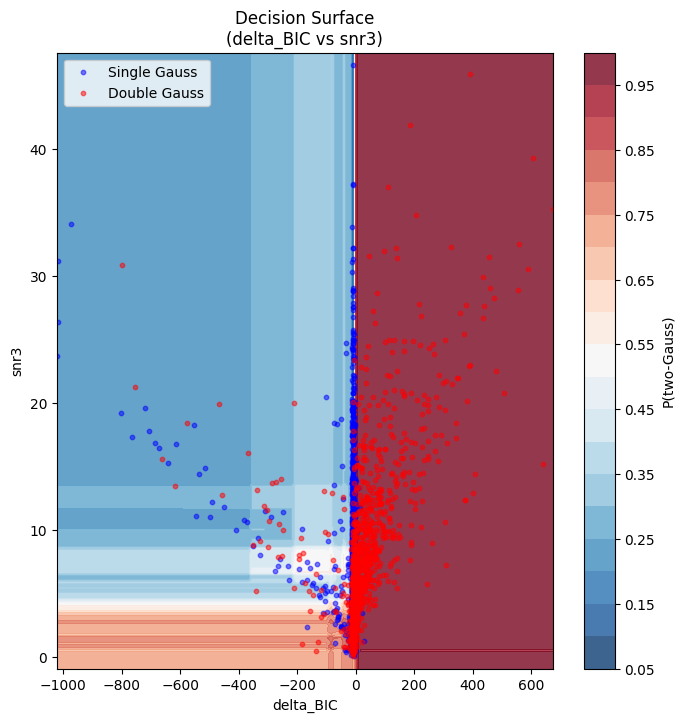

In [57]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, ax = plt.subplots(figsize=(8, 8))

# Plot in 2D using the two most important features
feat_x = 'delta_BIC'
feat_y = 'snr3'

x_min, x_max = X_test[feat_x].min() - 1, X_test[feat_x].max() + 1
y_min, y_max = X_test[feat_y].min() - 1, X_test[feat_y].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Build a dummy feature matrix with mean values for all other features
X_surface = pd.DataFrame(
    np.tile(X_test.mean().values, (xx.ravel().shape[0], 1)),
    columns=X_test.columns
)
X_surface[feat_x] = xx.ravel()
X_surface[feat_y] = yy.ravel()

Z = gb_model.predict_proba(X_surface)[:, 1].reshape(xx.shape)

contour = ax.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.8)
plt.colorbar(contour, ax=ax, label='P(two-Gauss)')
ax.scatter(X_test[feat_x][y_test_plot==0], X_test[feat_y][y_test_plot==0],
           c='blue', s=10, alpha=0.5, label='Single Gauss')
ax.scatter(X_test[feat_x][y_test_plot==1], X_test[feat_y][y_test_plot==1],
           c='red', s=10, alpha=0.5, label='Double Gauss')
ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.set_title(f'Decision Surface\n({feat_x} vs {feat_y})')
ax.legend()

# print(classification_report(y_test_plot, gb_model.predict(X_test),
#                              target_names=['Single Gauss', 'Double Gauss']))
# print(f'\nROC AUC:           {roc_auc:.3f}')
# print(f'Average Precision: {ap:.3f}')
# print(f'Best iteration:    {best_iter}')
# print(f'BIC accuracy:      {bic_correct.mean():.3f}')